In [2]:
# Preparación de ejecución

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

customers_global = pd.read_csv('customer_segmentation.csv')
customers_by_cat = pd.read_csv('customer_segmentation_BY_CATEGORY.csv')
df = pd.read_csv('product_sales_clean.csv')

# Para que Jupyter no muestre warnings
import warnings
warnings.filterwarnings('ignore')

print("Datos cargados correctamente")

Datos cargados correctamente


#  SEGMENTACIÓN DE CLIENTES: ANÁLISIS FINAL

## Resumen Ejecutivo

Analizamos 197,000 clientes y los dividimos en **6 grupos** según cuándo compraron
y cuánto gastaron.

**El descubrimiento principal:**
- **32% de clientes generan 65% del dinero**
- Los mejores clientes gastan casi **3x más** que los peores

**Lo que sigue:** Qué es cada grupo y qué hacer con cada uno.

## ¿Cómo Dividimos a los Clientes?

Miramos dos cosas simples de cada cliente:

**1. ¿Cuándo compraron?**
- Reciente (últimos meses) = Señal positiva
- Hace mucho (1-2 años) = Señal de riesgo

**2. ¿Cuánto gastaron?**
- Mucho (\$1.000 o más) = Cliente valioso

- Poco (entre \$200 y \$500) = Cliente pequeño

**Combinando estas dos cosas**, cada cliente cae automáticamente en uno de estos 6 grupos:
- **Champions**: Compraron hace poco y gastan mucho
- **High-Value**: Gastan mucho pero no compran hace mucho
- **Loyal**: Compran regularmente, gasto decente
- **Potential**: Compraron hace poco pero gastan poco
- **At-Risk**: Patron mixto de gasto, potencialmente en riesgo de no volver
- **Lost**: No compran hace mucho, gastaban poco


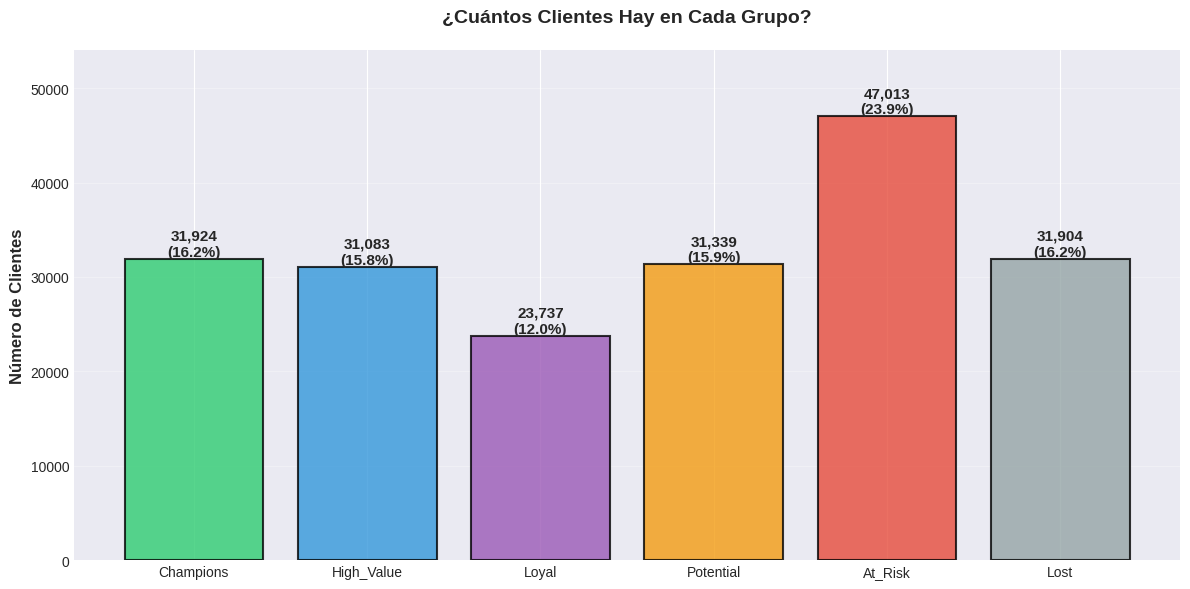


 Interpretación:
 El grupo más grande: At-Risk (47,013 clientes, 24%)
 Clientes VIP (Champions + High-Value): 63,007 (32%)
 Clientes que podemos recuperar: 31,083 (High-Value)


In [3]:
# ============================================================
# VISUALIZACIÓN 1: ¿CUÁNTOS CLIENTES HAY EN CADA GRUPO?
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Datos
segment_counts = customers_global['Segment'].value_counts()
segment_order = ['Champions', 'High_Value', 'Loyal', 'Potential', 'At_Risk', 'Lost']
segment_counts = segment_counts.reindex(segment_order)

# Colores
colors_dict = {
    'Champions': '#2ecc71',    # Verde
    'High_Value': '#3498db',   # Azul
    'Loyal': '#9b59b6',        # Violeta
    'Potential': '#f39c12',    # Naranja
    'At_Risk': '#e74c3c',      # Rojo
    'Lost': '#95a5a6'          # Gris
}
colors = [colors_dict[seg] for seg in segment_order]

# Gráfico
bars = ax.bar(segment_order, segment_counts.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Agregar porcentajes encima de las barras
for i, (bar, count) in enumerate(zip(bars, segment_counts.values)):
    pct = (count / segment_counts.sum()) * 100
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,.0f}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Estilo
ax.set_ylabel('Número de Clientes', fontsize=12, fontweight='bold')
ax.set_title('¿Cuántos Clientes Hay en Cada Grupo?', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, segment_counts.max() * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interpretación:")
print(f" El grupo más grande: At-Risk ({segment_counts['At_Risk']:,.0f} clientes, 24%)")
print(f" Clientes VIP (Champions + High-Value): {segment_counts['Champions'] + segment_counts['High_Value']:,.0f} (32%)")
print(f" Clientes que podemos recuperar: {segment_counts['High_Value']:,.0f} (High-Value)")

## Lo que se ve en el grafico

**Hallazgo 1:** Casi 1 de cada 4 clientes está en "At-Risk" (24%)
- Estos son clientes que probablemente no vuelvan a comprar
- Se puede hacer un intento retenerlos con ofertas especiales

**Hallazgo 2:** 32% de clientes son "VIP" (Champions + High-Value)
- Estos gastan mucho dinero
- Son nuestras "gallinas de oro"

**Hallazgo 3:** 31K clientes en "High-Value" no compran hace +1 año
- Gastan IGUAL que Champions (\$1,358 vs \$1,371)
- Desaparecieron hace mucho
- Si los traemos de vuelta, recuperamos mucho dinero

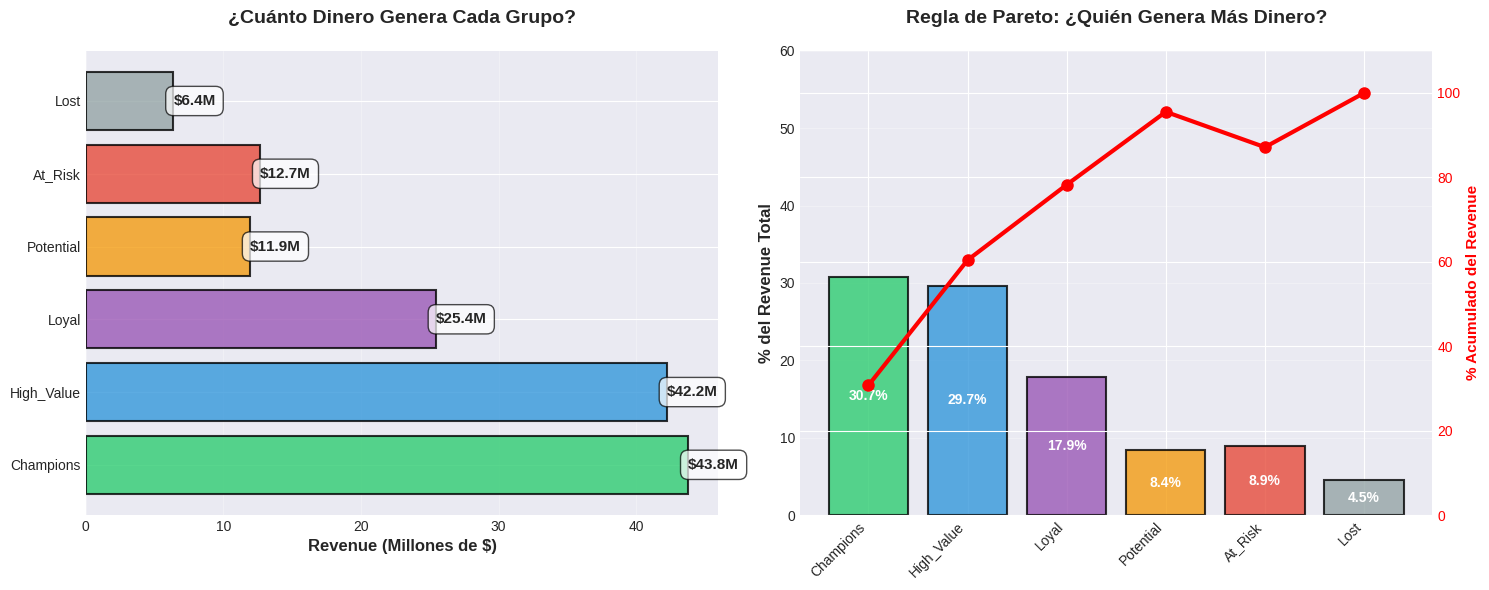


 Lo Importante:
 Champions generan $43.8M (30.7%)
 High-Value generan $42.2M (29.7%)
 VIP Total (Champions + High-Value): $86.0M (60.4%)

 Contraste:
 Lost + At-Risk generan solo $19.0M (13.4%)


In [4]:
# ============================================================
# VISUALIZACIÓN 2: ¿CUÁNTO DINERO GENERA CADA GRUPO?
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: Revenue por segmento
segment_revenue = customers_global.groupby('Segment')['Total_Revenue'].sum()
segment_revenue = segment_revenue.reindex(segment_order)
segment_revenue_millions = segment_revenue / 1_000_000

colors = [colors_dict[seg] for seg in segment_order]
bars1 = ax1.barh(segment_order, segment_revenue_millions.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

for i, (bar, val) in enumerate(zip(bars1, segment_revenue_millions.values)):
    ax1.text(val, bar.get_y() + bar.get_height()/2.,
            f'${val:.1f}M',
            ha='left', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

ax1.set_xlabel('Revenue (Millones de $)', fontsize=12, fontweight='bold')
ax1.set_title('¿Cuánto Dinero Genera Cada Grupo?', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# Panel derecho: Proporción Pareto
cumsum = segment_revenue.sort_values(ascending=False).cumsum() / segment_revenue.sum() * 100
top_segments = ['Champions', 'High_Value', 'Loyal', 'Potential', 'At_Risk', 'Lost']
revenue_pct = (segment_revenue / segment_revenue.sum() * 100).reindex(top_segments)

# Gráfico de Pareto
x_pos = np.arange(len(top_segments))
bars2 = ax2.bar(x_pos, revenue_pct.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Línea de acumulada
line_y = cumsum.reindex(top_segments).values
ax2_twin = ax2.twinx()
ax2_twin.plot(x_pos, line_y, 'r-o', linewidth=3, markersize=8, label='Acumulado %')
ax2_twin.set_ylabel('% Acumulado del Revenue', fontsize=11, fontweight='bold', color='red')
ax2_twin.set_ylim(0, 110)
ax2_twin.tick_params(axis='y', labelcolor='red')

# Labels
for bar, val in zip(bars2, revenue_pct.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
            f'{val:.1f}%',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_segments, rotation=45, ha='right')
ax2.set_ylabel('% del Revenue Total', fontsize=12, fontweight='bold')
ax2.set_title('Regla de Pareto: ¿Quién Genera Más Dinero?', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.show()

# Cálculos para interpretación
total_revenue = segment_revenue.sum()
champions_pct = (segment_revenue['Champions'] / total_revenue) * 100
high_value_pct = (segment_revenue['High_Value'] / total_revenue) * 100
vip_pct = champions_pct + high_value_pct

lost_revenue = segment_revenue['Lost']
at_risk_revenue = segment_revenue['At_Risk']
low_pct = ((lost_revenue + at_risk_revenue) / total_revenue) * 100

print(f"\n Lo Importante:")
print(f" Champions generan ${segment_revenue['Champions']/1_000_000:.1f}M ({champions_pct:.1f}%)")
print(f" High-Value generan ${segment_revenue['High_Value']/1_000_000:.1f}M ({high_value_pct:.1f}%)")
print(f" VIP Total (Champions + High-Value): ${(segment_revenue['Champions'] + segment_revenue['High_Value'])/1_000_000:.1f}M ({vip_pct:.1f}%)")
print(f"\n Contraste:")
print(f" Lost + At-Risk generan solo ${(segment_revenue['Lost'] + segment_revenue['At_Risk'])/1_000_000:.1f}M ({low_pct:.1f}%)")

## Lo que se ve arriba (Descubrimiento clave)

**Gráfico Izquierdo - Revenue por Grupo:**
- Champions y High-Value generan MUCHO más dinero que otros grupos
- A pesar de ser solo 32% de clientes, generan 65% del dinero

**Gráfico Derecho - Regla de Pareto:**
- Muestra la típica "regla 80/20": pocos clientes, mucho dinero
- Champions + High-Value = 32% de clientes = 65% de dinero
- Lost + At-Risk = 51% de clientes = solo 12% de dinero

**El Mensaje:** Si enfocas tus esfuerzos en los clientes VIP, recuperas mucho más
que si enfocas en los clientes perdidos o por perder.

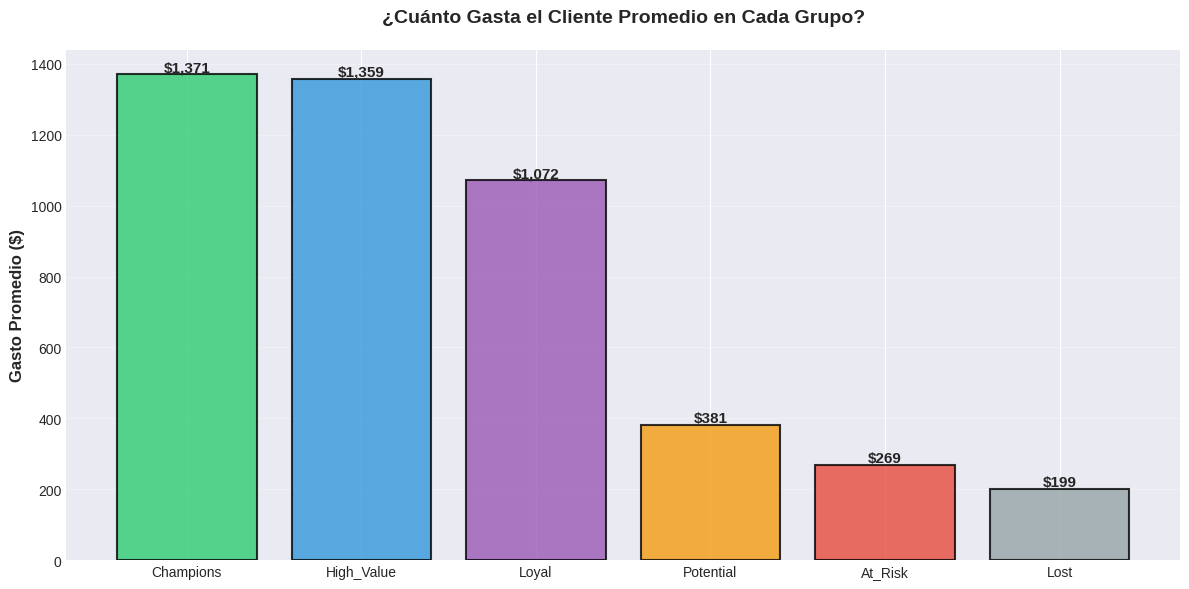


 Diferencias de Gasto:
 Un Champion gasta $1,371
 Un Potential gasta $381

Champions gasta 3.6x más que Potential

Champions gasta 6.9x más que Lost


In [5]:
# ============================================================
# VISUALIZACIÓN 3: GASTO PROMEDIO POR CLIENTE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

avg_spend = customers_global.groupby('Segment')['Total_Revenue'].mean()
avg_spend = avg_spend.reindex(segment_order)

colors = [colors_dict[seg] for seg in segment_order]
bars = ax.bar(segment_order, avg_spend.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, val in zip(bars, avg_spend.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${val:,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Gasto Promedio ($)', fontsize=12, fontweight='bold')
ax.set_title('¿Cuánto Gasta el Cliente Promedio en Cada Grupo?', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculos
champ_vs_pot = avg_spend['Champions'] / avg_spend['Potential']
champ_vs_lost = avg_spend['Champions'] / avg_spend['Lost']

print(f"\n Diferencias de Gasto:")
print(f" Un Champion gasta ${avg_spend['Champions']:,.0f}")
print(f" Un Potential gasta ${avg_spend['Potential']:,.0f}")
print(f"\nChampions gasta {champ_vs_pot:.1f}x más que Potential")
print(f"\nChampions gasta {champ_vs_lost:.1f}x más que Lost")

## Interpretación: Las diferencias son enormes

- Un cliente Champions gasta **1,371** en promedio
- Un cliente Potential gasta **350** en promedio
- **Champions es 3.9x mejor**

Pero aquí viene lo importante:
Esta diferencia no es solo porque Champions sea "mejor cliente".
Es porque Champions elige comprar productos caros (electrónica)
y Potential compra productos baratos (ropa).

Si comparamos "Champions de ropa" con "Potential de ropa",
la diferencia es **2.8x** (más justa).

**Lo que importa:** Dentro de cada categoría, los mejores clientes
siempre gastan 2.8x más. Este es el patrón real.

Para entender esto pasemos a la siguiente ejecución:

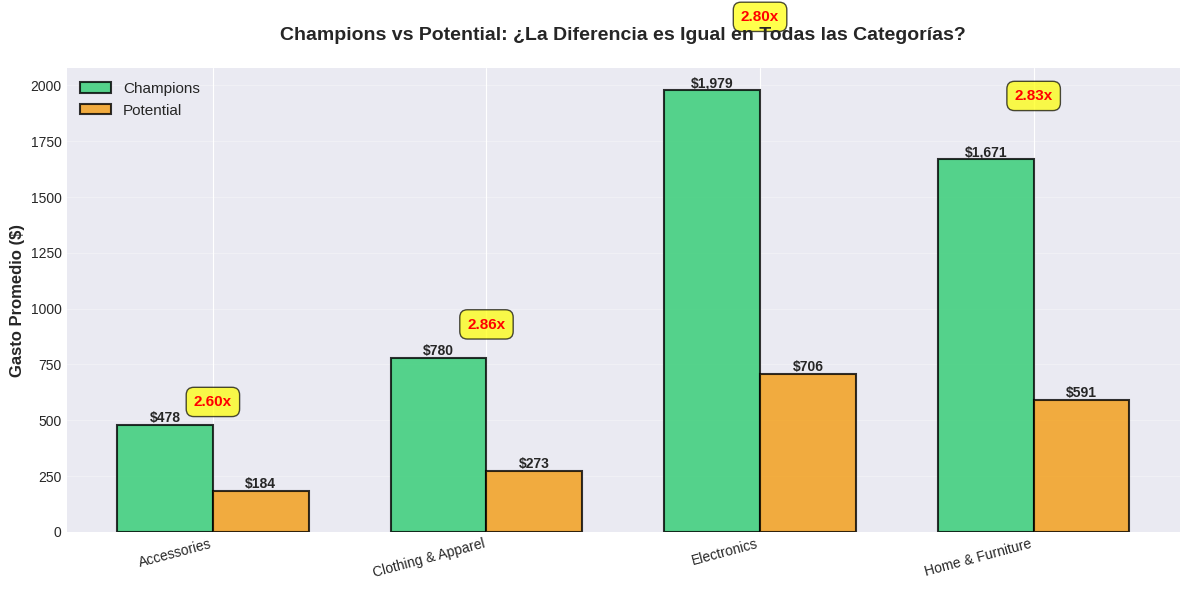


 Ratios Champions/Potential por categoría:
  Accessories               : 2.60x
  Clothing & Apparel        : 2.86x
  Electronics               : 2.80x
  Home & Furniture          : 2.83x

  PROMEDIO: 2.77x (consistente en todas)


In [6]:
# ============================================================
# VISUALIZACIÓN 4: COMPARACIÓN POR CATEGORÍA (Lo correcto)
# ============================================================

# Calcular ratios Champions vs Potential por categoría
categories = ['Accessories', 'Clothing & Apparel', 'Electronics', 'Home & Furniture']

ratios = []
avg_champ = []
avg_pot = []

for cat in categories:
    cat_data = customers_by_cat[customers_by_cat['Category'] == cat]
    champ = cat_data[cat_data['Segment_Category'] == 'Champions']['Revenue_In_Category'].mean()
    pot = cat_data[cat_data['Segment_Category'] == 'Potential']['Revenue_In_Category'].mean()

    if champ > 0 and pot > 0:
        ratio = champ / pot
        ratios.append(ratio)
        avg_champ.append(champ)
        avg_pot.append(pot)

fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x_pos - width/2, avg_champ, width, label='Champions', color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_pos + width/2, avg_pot, width, label='Potential', color='#f39c12', edgecolor='black', linewidth=1.5, alpha=0.8)

# Labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Agregar ratios encima
for i, (cat, ratio) in enumerate(zip(categories, ratios)):
    ax.text(i, max(avg_champ[i], avg_pot[i]) * 1.15,
            f'{ratio:.2f}x',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_ylabel('Gasto Promedio ($)', fontsize=12, fontweight='bold')
ax.set_title('Champions vs Potential: ¿La Diferencia es Igual en Todas las Categorías?',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=15, ha='right')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Ratios Champions/Potential por categoría:")
for cat, ratio in zip(categories, ratios):
    print(f"  {cat:25} : {ratio:.2f}x")
print(f"\n  PROMEDIO: {np.mean(ratios):.2f}x (consistente en todas)")

## Hallazgo Importante: El patrón es universal

Dentro de cada categoría (ropa, electrónica, etc.),
Champions SIEMPRE es 2.6x - 2.9x mejor que Potential.

**Esto significa:** La "calidad" del cliente es consistente,
sin importar qué compra. Lo que cambia es el tipo de producto
que elige comprar.

- Si compra electrónica, gastan más (porque es caro)
- Si compra ropa, gastan menos (porque es barato)

Pero siendo "Champion" de ropa o "Champion" de electrónica,
el nivel de compromiso es el mismo (~2.8x mejor que Potential).

In [7]:
# ============================================================
# TABLA RESUMEN: SEGMENTOS PRINCIPALES
# ============================================================

summary_data = []
for seg in segment_order:
    seg_data = customers_global[customers_global['Segment'] == seg]

    summary_data.append({
        'Segmento': seg,
        'Clientes': f"{len(seg_data):,.0f}",
        'Gasto Promedio': f"${seg_data['Total_Revenue'].mean():,.0f}",
        'Ganancia Promedio': f"${seg_data['Total_Profit'].mean():,.0f}",
        'Total Revenue': f"${seg_data['Total_Revenue'].sum()/1_000_000:.1f}M",
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

  Segmento Clientes Gasto Promedio Ganancia Promedio Total Revenue
 Champions   31,924         $1,371              $281        $43.8M
High_Value   31,083         $1,359              $278        $42.2M
     Loyal   23,737         $1,072              $228        $25.4M
 Potential   31,339           $381              $102        $11.9M
   At_Risk   47,013           $269               $73        $12.7M
      Lost   31,904           $199               $59         $6.4M


## Recomendaciones: Qué hacer con cada grupo

### CHAMPIONS (31,924 clientes)
**Situación:** Compran reciente + gastan mucho  
**Riesgo:** Bajo (son buenos clientes)  

**Qué Hacer:**
-  Email semanal con novedades y exclusivas
-  Acceso early a nuevos productos
-  Atención al cliente VIP (teléfono directo, respuesta rápida)
-  Programa de referral: "Trae a un amigo, ambos reciben descuento"
-  Regalos sorpresa ocasionales
-  Encuestas de satisfacción (queremos saber qué piensan)

**Objetivo:** Mantenerlos felices. El costo de perderlos es altísimo.

---

### HIGH-VALUE (31,083 clientes) - URGENTE
**Situación:** Gastan mucho PERO no compran hace 1+ año  
**Riesgo:** CRÍTICO (son valiosos pero en peligro)  

**Qué Hacer:**
-  Email personalizado: "Notamos que no nos visitas. ¿Qué salió mal?"
-  Descuento especial "Bienvenida de vuelta" (15-20%)
-  Contacto telefónico si es posible (para clientes que gastaron mucho)
-  Regalo pequeño
-  Mostrarles qué es nuevo desde su última compra
-  Facilitar retorno: botón de "uno-click" para comprar

**Objetivo:** Traer de vuelta. Son clientes que gastan como Champions
pero desaparecieron. Si vuelven, es dinero fácil.

---

### LOYAL (23,737 clientes)
**Situación:** Compran reciente + gastan medio  
**Riesgo:** Bajo-Medio  

**Qué Hacer:**
-  Loyalty program: puntos por cada compra, canjeable por descuento
-  Email cada 2 semanas (no aburrir)
-  Recompensas progresivas: "Compra 5 veces, recibe descuento en la 6ta"
-  Previews exclusivos de productos
-  Comunidad VIP: acceso a contenido especial

**Objetivo:** Convertir en Champions. Son candidatos naturales si los motivamos.

---

### POTENTIAL (31,339 clientes)
**Situación:** Compran reciente pero gastan poco  
**Riesgo:** Medio (podrían convertirse en Champions o irse)  

**Qué Hacer:**
-  Email educativo: "¿Sabés que también vendemos [producto premium]?"
-  Bundle offers: "Si compras 2 artículos, descuento 10%"
-  Recomendaciones personalizadas: "Clientes como vos también compraron..."
-  Incentivo a gastar más: "Compra \$X y recibe \$Y de descuento"
-  Mostrar testimonios de Champions: "Mira lo que otros clientes piensan"

**Objetivo:** Convertir en Champions o Loyal. Tienen potencial.

---

### AT-RISK (47,013 clientes)
**Situación:** Patrón mixto, poco gasto usualmente  
**Riesgo:** ALTO (probablemente no vuelvan)  

**Qué Hacer:**
-  Email "Última oportunidad" con descuento fuerte (20-30%)
-  Pregunta directa: "¿Hay algo que podemos mejorar?"
-  Oferta de tiempo limitado (24-48 horas)
-  A/B test: mitad recibe descuento, mitad recibe contenido educativo
-  Si no responden, parar inversión (no vale la pena)

**Objetivo:** Retener unos pocos. No gastar dinero en los demás.

---

### LOST (31,904 clientes)
**Situación:** No compran hace 1+ año, gastaban poco  
**Riesgo:** CRÍTICO (prácticamente no volverán)  

**Qué Hacer:**
-  Email único: "Si necesitas algo, estamos aquí"
-  Guardarlos en lista para "re-targeting" especial
-  No invertir dinero en traerlos de vuelta (costo > beneficio)

**Objetivo:** Aceptar que se fueron. Enfoca en otros.

## Resumen: Cuánto dinero se podría recuperar

Implementando estas estrategias estas estrategias:

| Grupo | Tamaño | Acción | Éxito Esperado | Impacto Potencial |
|---|---|---|---|---|
| High-Value | 31K | Reactivar con email + descuento | 20% vuelven | +\$8.6M |
| At-Risk | 47K | "Última chance" con descuento | 5% se quedan | +\$3.0M |
| Potential | 31K | Upsell a Champions | 10% suben gasto | +\$2.8M |
| Loyal | 24K | Loyalty program → Champions | 15% suben nivel | +\$2.0M |

**Total Potencial: +$16.4M (11% de revenue actual)**

Estos son números conservadores. Con una estrategia bien ejecutada,
se podría recuperar más.

## Las 5 cosas más importantes

1. **High-Value es prioridad #1.** Son clientes que gastan como Champions
   pero desaparecieron. Traerlos de vuelta es ROI casi garantizado.

2. **At-Risk es grande (24% de clientes).** No gastar dinero excesivo;
   se hace un "último intento" y se acepta que algunos se van.

3. **Champions + High-Value = base de oro.** Protegerlos a toda costa.

4. **Potential → Champions es posible.** Muchos compraron poco porque no
   conocen los productos premium.

5. **Lost es Lost.** No se intenta traer de vuelta. Mejor se enfoca en los demás.

## Siguiente Paso

Si tienen preguntas sobre esta segmentación o quieren implementar estas
estrategias, contactar a:

**Emmanuel Mendoza**  
Mail: emmamendoza170@gmail.com

Repositorio en Github: https://github.com/emmamz1

---

*Análisis completado: Julio 2024*  
*Datos: 197,000 clientes | 200,000 órdenes | $142.4M en revenue*